# Ridge Regression with Gradient Descent

- Since its regression, so can be solved using both OLS and Gradient Descent.

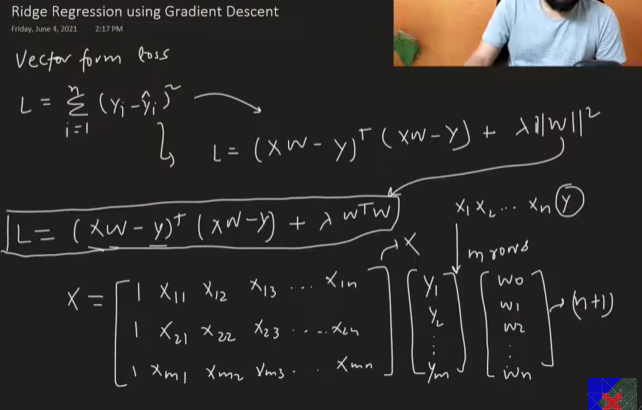

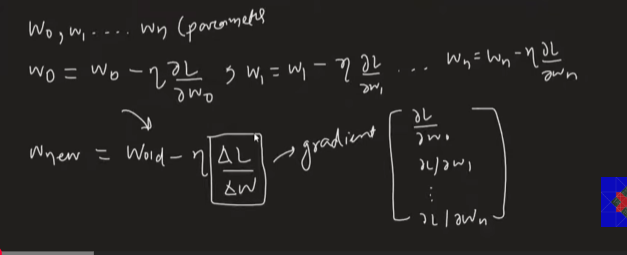

So we need to find the derivative of the cost function with respect to the W vector, and then update the weights using the learning rate.

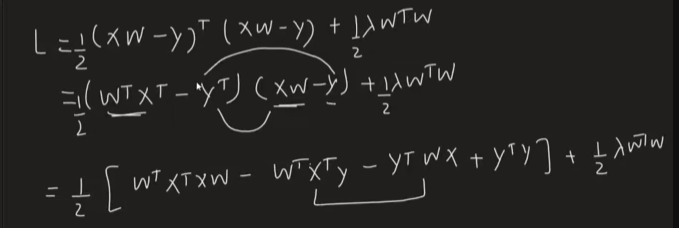

- The $1/2$ is multiplied to make the derivative simpler

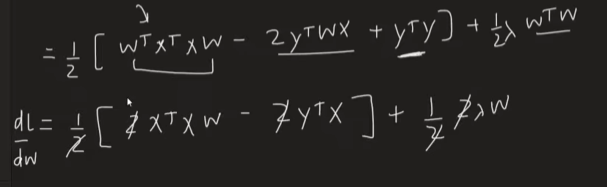

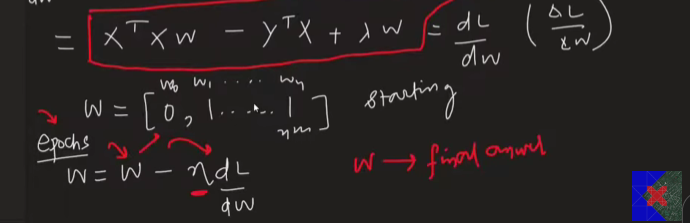

- Initialize $W$ with 

$$
W = [0, 1 ,1 ... 1]
$$


- A small error in the above formula from the step where we both the terms were equal, so take the other equal term
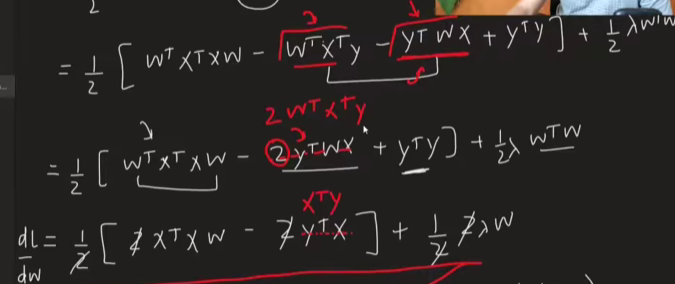

- So the correct gradient formula is:

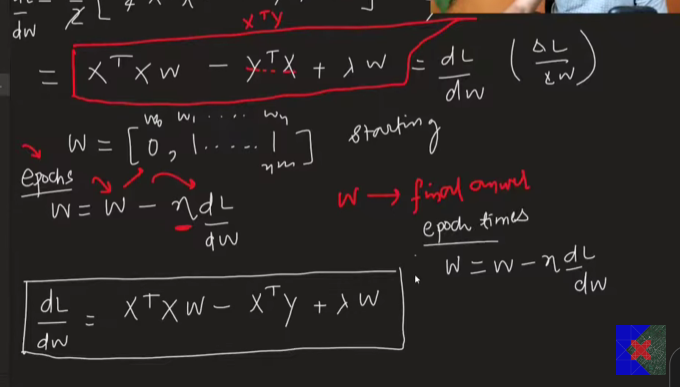

In [1]:
from sklearn.datasets import load_diabetes
from sklearn.metrics import r2_score
import numpy as np

In [2]:
X,y = load_diabetes(return_X_y=True)

In [3]:
from sklearn.model_selection import train_test_split

In [4]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=4)

In [5]:
from sklearn.linear_model import SGDRegressor

### Ridge regression using sklearn SGDRegressor class

- penalty = 'l2' is used to specify that we want to use Ridge regression (L2 regularization)

- alpha is the regularization strength, and it is equivalent to the lambda parameter in the cost function

- eta0 is the learning rate


In [6]:
reg = SGDRegressor(penalty='l2',max_iter=500,eta0=0.1,learning_rate='constant',alpha=0.001)

In [7]:
reg.fit(X_train,y_train)

y_pred = reg.predict(X_test)
print("R2 score",r2_score(y_test,y_pred))
print(reg.coef_)
print(reg.intercept_)

R2 score 0.4099858996354583
[  51.3025663  -143.79306377  357.61444181  264.73395957    0.92562571
  -48.72966269 -169.95193745  140.06637385  319.57383149  108.03610405]
[140.10357137]


### Ridge Regression Using Ridge class of sklearn

- Use solver = 'sparse_cg' , it is an iterative method 

In [8]:
from sklearn.linear_model import Ridge

reg = Ridge(alpha=0.001, max_iter=500,solver='sparse_cg')

In [9]:
reg.fit(X_train,y_train)

y_pred = reg.predict(X_test)
print("R2 score",r2_score(y_test,y_pred))
print(reg.coef_)
print(reg.intercept_)

R2 score 0.4625010162009602
[  34.52192661 -290.84083974  482.4018151   368.06786776 -852.44872998
  501.59160516  180.11115631  270.76334212  759.73534588   37.49135628]
151.10198517848258


### By the Ridge Class coded using gradient descent

In [13]:
class MeraRidgeGD:
    
    def __init__(self,epochs,learning_rate,alpha):
        
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.alpha = alpha
        self.coef_ = None
        self.intercept_ = None
        
    def fit(self,X_train,y_train):
        
        self.coef_ = np.ones(X_train.shape[1])
        self.intercept_ = 0
        W = np.insert(self.coef_,0,self.intercept_)
        
        X_train = np.insert(X_train,0,1,axis=1)
        
        for i in range(self.epochs):
            W_der = np.dot(X_train.T,X_train).dot(W) - np.dot(X_train.T,y_train) + self.alpha*W
            W = W - self.learning_rate*W_der
        
        self.coef_ = W[1:]
        self.intercept_ = W[0]
    
    def predict(self,X_test):
        
        return np.dot(X_test,self.coef_) + self.intercept_

In [14]:
reg = MeraRidgeGD(epochs=500,alpha=0.001,learning_rate=0.005)

In [15]:
reg.fit(X_train,y_train)

y_pred = reg.predict(X_test)
print("R2 score",r2_score(y_test,y_pred))
print(reg.coef_)
print(reg.intercept_)

R2 score 0.4738018280260914
[  46.65050914 -221.3750037   452.12080647  325.54248128  -29.09464178
  -96.47517735 -190.90017011  146.32900372  400.80267299   95.09048094]
150.86975316713472


- In similar way you can implement Ridge Regression using Stochastic Gradient Descent, Mini Batch Gradient Descent, etc.